# Pruebas pipeline
Este código pretende entender y conseguir un pipeline definitivo. 

## Funciones necesarias

In [67]:
#Import libraries
import numpy as np
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline
from denoising_fun import  denoise_spectrum_uwt
import os
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------
# 0. Leer archivos
# --------------------------------------
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
# --------------------------------------
# 1. Denoising por Wavelet (UWT + sigma clipping)
# --------------------------------------
def denoise_spectrum_uwt(spectrum, wavelet_name='bior3.3', level=None, threshold_sigma=3, method='mad', n_iter_supercam=5):
    """
    Aplica reducción de ruido (denoising) a un espectro usando UWT y sigma clipping.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wavelet_name : str, opcional
        Nombre del wavelet a utilizar. Por defecto 'bior3.3'.
    level : int, opcional
        Nivel de descomposición wavelet. Si no se especifica, se calcula automáticamente el máximo.
    threshold_sigma : float, opcional
        Umbral de sigma para eliminar coeficientes de detalle (por defecto 3σ).
    method : str, opcional
        Método de sigma clipping: 'mad' o 'supercam'.
    n_iter_supercam : int, opcional
        Número de iteraciones para el método supercam.

    Devuelve:
    ---------
    spectrum_denoised : np.ndarray
        Espectro reconstruido con el ruido eliminado.
    """

    def pad_to_multiple(x, base):
        remainder = len(x) % base
        if remainder == 0:
            return x, 0
        pad_size = base - remainder
        x_padded = np.pad(x, (0, pad_size), mode='edge')
        return x_padded, pad_size

    def sigma_clipping_supercam(coeffs, n_iter=5, threshold_sigma=3):
        filtered_coeffs = []
        for cA, cD in coeffs:
            cD_abs = np.abs(cD)
            mask = np.ones_like(cD_abs, dtype=bool)
            for _ in range(n_iter):
                sigma = np.std(cD_abs[mask])
                mask = cD_abs < (threshold_sigma * sigma)
            sigma_final = np.std(cD_abs[mask])
            threshold = threshold_sigma * sigma_final
            cD_filtered = np.where(cD_abs < threshold, 0, cD)
            filtered_coeffs.append((cA, cD_filtered))
        return filtered_coeffs

    spectrum = np.asarray(spectrum)
    original_len = len(spectrum)

    if level is None:
        # Asegurar que la longitud sea par (agregar padding si es impar)
        if original_len % 2 != 0:
            spectrum = np.pad(spectrum, (0, 1), mode='edge')  # duplica el último valor
            original_len += 1
        level = pywt.swt_max_level(original_len)

    spectrum_padded, pad_size = pad_to_multiple(spectrum, 2 ** level)
    coeffs = pywt.swt(spectrum_padded, wavelet_name, level=level)

    if method == 'mad':
        denoised_coeffs = []
        for cA, cD in coeffs:
            sigma = np.median(np.abs(cD)) / 0.6745
            cD_filtered = np.where(np.abs(cD) < threshold_sigma * sigma, 0, cD)
            denoised_coeffs.append((cA, cD_filtered))
    elif method == 'supercam':
        denoised_coeffs = sigma_clipping_supercam(coeffs, n_iter=n_iter_supercam, threshold_sigma=threshold_sigma)
    else:
        raise ValueError("El parámetro 'method' debe ser 'mad' o 'supercam'.")

    spectrum_denoised = pywt.iswt(denoised_coeffs, wavelet_name)
    return spectrum_denoised[:original_len]

# --------------------------------------
# 2. Eliminación del continuo (por defecto: Robust Baseline Estimation)
# --------------------------------------
def robust_baseline_estimation(spectrum, span=0.1, max_iter=5, b=3.5, tol=1e-3):
    """
    Estima la línea base de un espectro utilizando el algoritmo RBE.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    span : float, opcional
        Proporción del total de puntos a utilizar en la regresión local. Por defecto 0.1 (10%).
    max_iter : int, opcional
        Número máximo de iteraciones para la convergencia. Por defecto 5.
    b : float, opcional
        Constante de ajuste para los pesos bi-square de Tukey. Por defecto 3.5.
    tol : float, opcional
        Tolerancia para la convergencia. Por defecto 1e-3.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    x = np.arange(len(spectrum))
    n = len(spectrum)
    half_window = int(np.ceil(span * n / 2))

    # Estimación inicial de la línea base usando LOWESS
    baseline = np.copy(spectrum)
    for i in range(n):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        x_local = x[start:end]
        y_local = spectrum[start:end]
        weights = tricube_weight((x_local - x[i]) / half_window)
        p = np.polyfit(x_local, y_local, 1, w=weights)
        baseline[i] = np.polyval(p, x[i])

    # Iteraciones para la estimación robusta
    for iteration in range(max_iter):
        residuals = spectrum - baseline
        sigma = np.median(np.abs(residuals)) / 0.6745
        residuals_standardized = residuals / sigma
        weights_robust = tukey_biweight(residuals_standardized, b)
        baseline_new = np.copy(spectrum)
        for i in range(n):
            start = max(0, i - half_window)
            end = min(n, i + half_window + 1)
            x_local = x[start:end]
            y_local = spectrum[start:end]
            weights = tricube_weight((x_local - x[i]) / half_window) * weights_robust[start:end]
            if np.sum(weights) > 0:
                p = np.polyfit(x_local, y_local, 1, w=weights)
                baseline_new[i] = np.polyval(p, x[i])
            else:
                baseline_new[i] = baseline[i]
        # Comprobar convergencia
        if np.linalg.norm(baseline_new - baseline) < tol:
            break
        baseline = baseline_new

    

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline
    spectrum_corrected[spectrum_corrected < 0] = 0
    return baseline, spectrum_corrected

def tricube_weight(x):
    """Función de peso tricúbico."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, (1 - abs_x**3)**3, 0)

def tukey_biweight(residuals, b=3.5):
    """Pesos bi-square de Tukey asimétricos."""
    weights = np.ones_like(residuals)
    mask = residuals >= 0
    weights[mask] = (1 - (residuals[mask] / b)**2)**2
    weights[residuals >= b] = 0
    return weights

# --------------------------------------
# 3. Stiching de espectros
# --------------------------------------
def stitch_spectra(spectra, wavelengths):
    """
    Realiza el 'stitching' de múltiples espectros ajustando sus intensidades en zonas de solapamiento.

    Parámetros:
    -----------
    spectra : list of np.ndarray
        Lista de espectros a unir.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes a cada espectro.

    Devuelve:
    ---------
    stitched_spectra : list of np.ndarray
        Lista de espectros corregidos con los coeficientes de stitching aplicados.
    """
    #Declaración de los intervalos de solapamiento
    i1 = (wavelengths[1][1], wavelengths[0][len(wavelengths[0])-1])
    i2 = (wavelengths[2][1], wavelengths[1][len(wavelengths[1])-1])
    i3 = (wavelengths[3][1], wavelengths[2][len(wavelengths[2])-1])
    #Aislamiento de los intervalos de solapamiento
    datos_UV1_fil1 = spectra[0][(wavelengths[0] >= i1[0]) & (wavelengths[0] <= i1[1])]
    datos_UV2_fil1 = spectra[1][(wavelengths[1] >= i1[0]) & (wavelengths[1] <= i1[1])]
    datos_UV2_fil2 = spectra[1][(wavelengths[1] >= i2[0]) & (wavelengths[1] <= i2[1])]
    datos_VIS_fil2 = spectra[2][(wavelengths[2] >= i2[0]) & (wavelengths[2] <= i2[1])]
    datos_VIS_fil3 = spectra[2][(wavelengths[2] >= i3[0]) & (wavelengths[2] <= i3[1])]
    datos_NIR_fil3 = spectra[3][(wavelengths[3] >= i3[0]) & (wavelengths[3] <= i3[1])]
    #Extracción de las medianas
    mediana_UV1_fil1 = np.median(datos_UV1_fil1)
    mediana_UV2_fil1 = np.median(datos_UV2_fil1)
    mediana_UV2_fil2 = np.median(datos_UV2_fil2)
    mediana_VIS_fil2 = np.median(datos_VIS_fil2)
    mediana_VIS_fil3 = np.median(datos_VIS_fil3)
    mediana_NIR_fil3 = np.median(datos_NIR_fil3)
    #Cálculo de los coeficientes
    coef1 = mediana_UV2_fil1/mediana_UV1_fil1
    coef2 = mediana_VIS_fil2/mediana_UV2_fil2
    coef3 = mediana_NIR_fil3/mediana_VIS_fil3
    #Aplicación de los coeficientes
    datos_UV1_corr = spectra[0]*coef3*coef2*coef1
    datos_UV2_corr = spectra[1]*coef3*coef2
    datos_VIS_corr = spectra[2]*coef3
    datos_NIR_corr = spectra[3]
    sitich_coefs = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]

    return sitich_coefs


# --------------------------------------
# 3. Plot spectra
# --------------------------------------
def plot_spectra(spectra, wavelengths,nombres = ['UV1', 'UV2', 'VIS', 'NIR'], title="Espectros originales"):
    """
    Plotea múltiples espectros en la misma figura.

    Parámetros:
    ------------
    spectra : list of np.ndarray
        Lista de espectros a plotear.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes a cada espectro.
    title : str, opcional
        Título del gráfico. Por defecto "Espectros originales".

    Devuelve:
    ---------
    None
    """
    plt.figure(figsize=(10, 4))
    for i, (spectrum, wavelength) in enumerate(zip(spectra, wavelengths)):
        plt.plot(wavelength, spectrum, label=f'{nombres[i]}')
    plt.title(title)
    plt.xlabel('Longitud de onda (nm)')
    plt.ylabel('Intensidad')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


## Leer archivos

In [68]:
ruta_espectros = os.path.join('..', 'Spectra', '20250321_First_test')

UV1 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

# Nombres y organización
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
spectra = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

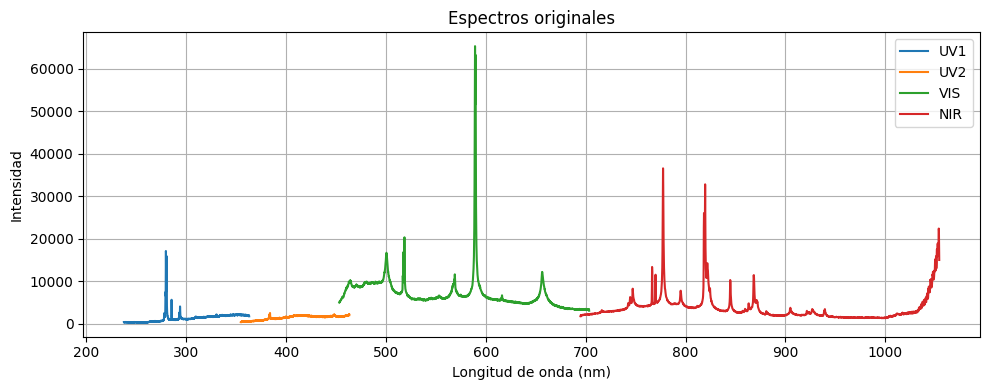

In [45]:
#plot original
plot_spectra(spectra, wavelengths)

## Pipeline 1. Stiching->Denoising->Baseline removal

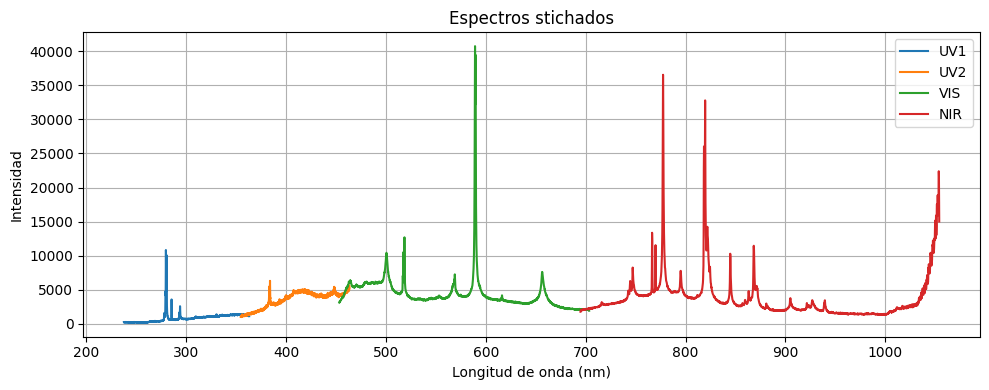

In [56]:
#Stiching
spectra_stiched = stitch_spectra(spectra, wavelengths)
plot_spectra(spectra_stiched, wavelengths, title="Espectros stichados")

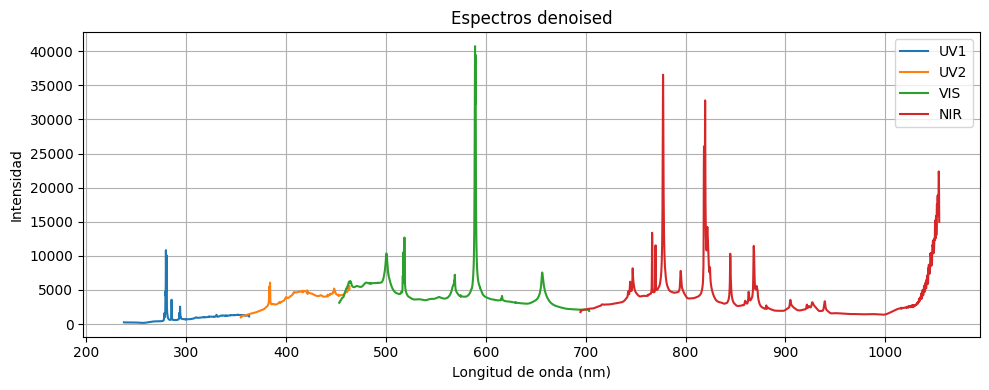

In [57]:
#Denoising
spectra_denoised = [denoise_spectrum_uwt(spectrum) for spectrum in spectra_stiched]
plot_spectra(spectra_denoised, wavelengths, nombres, title="Espectros denoised")

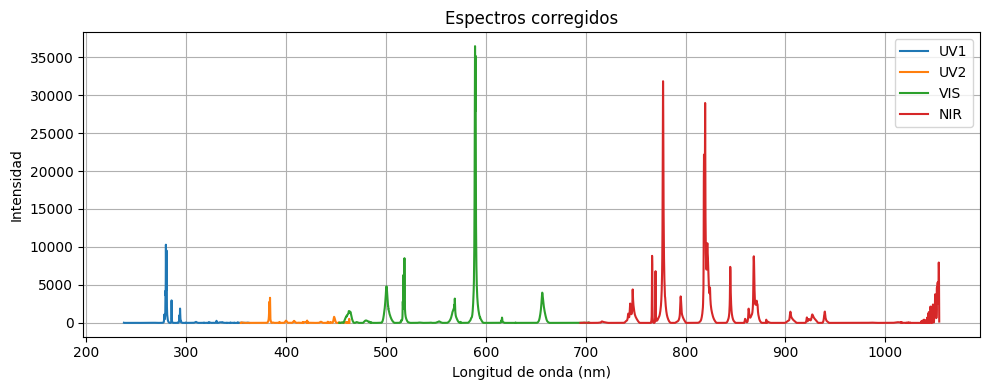

In [58]:
#bckground removal
spectra_corrected = [robust_baseline_estimation(spectrum)[1] for spectrum in spectra_denoised]
plot_spectra(spectra_corrected, wavelengths, nombres, title="Espectros corregidos")

## Pipeline 2. Denoising->Stiching->Baseline removal

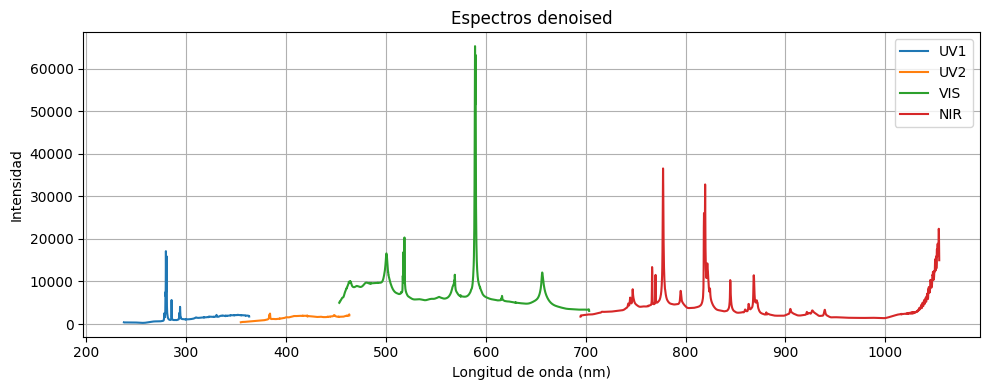

In [53]:
#Denoising
spectra_denoised_2 = [denoise_spectrum_uwt(spectrum) for spectrum in spectra]
plot_spectra(spectra_denoised_2, wavelengths, title="Espectros denoised")

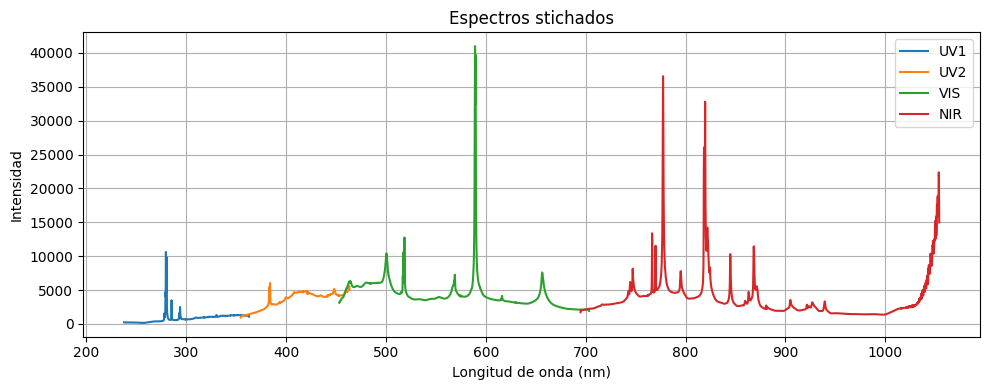

In [54]:
#Stiching
spectra_stiched_2 = stitch_spectra(spectra_denoised_2, wavelengths)
plot_spectra(spectra_stiched_2, wavelengths, title="Espectros stichados")

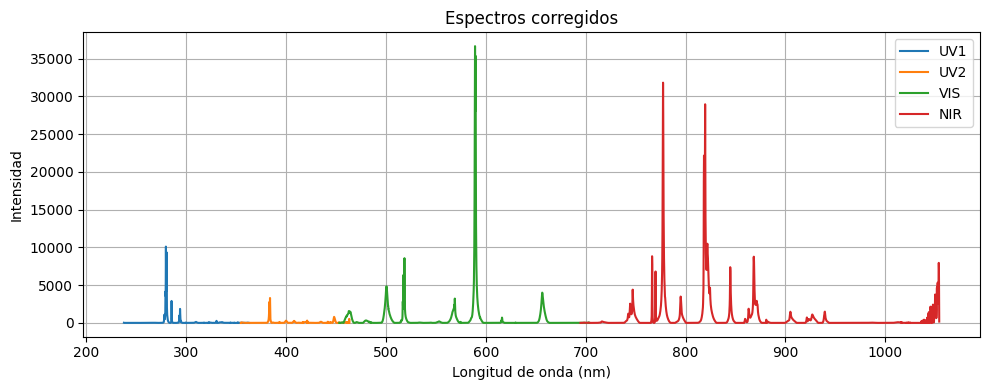

In [55]:
#bckground removal
spectra_corrected_2 = [robust_baseline_estimation(spectrum)[1] for spectrum in spectra_stiched_2]
plot_spectra(spectra_corrected, wavelengths, nombres, title="Espectros corregidos")

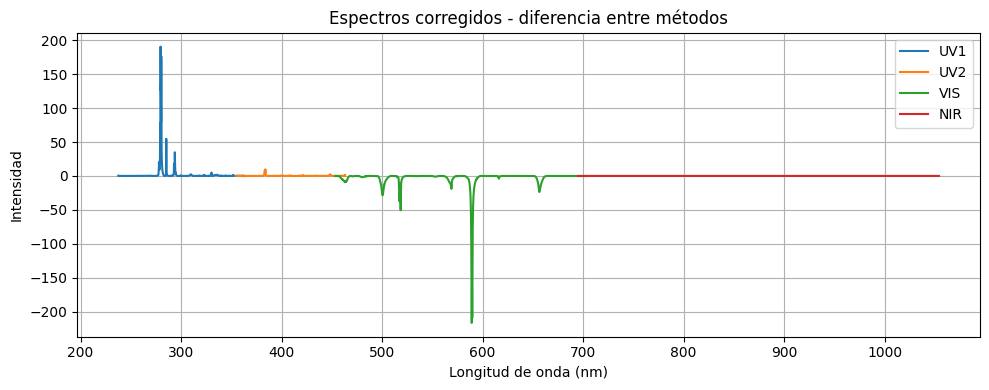

In [59]:
#restamos ambos método para observar si hay diferencias mayores
spectra_diff = [spectrum - spectrum_2 for spectrum, spectrum_2 in zip(spectra_corrected, spectra_corrected_2)]
plot_spectra(spectra_diff, wavelengths, nombres, title="Espectros corregidos - diferencia entre métodos")